In [1]:
#Name: Bilal Khalid  
#Course: Advanced Big Data and Data Mining (MSCS-634-M20)  
#Lab Title: Classification Using KNN and RNN Algorithms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print(wine.feature_names)
print(wine.target_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [3]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

In [8]:
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    
    print(f"k={k}, Accuracy={acc}")

k=1, Accuracy=0.9444444444444444
k=5, Accuracy=0.9444444444444444
k=11, Accuracy=0.9444444444444444
k=15, Accuracy=0.9722222222222222
k=21, Accuracy=0.9444444444444444


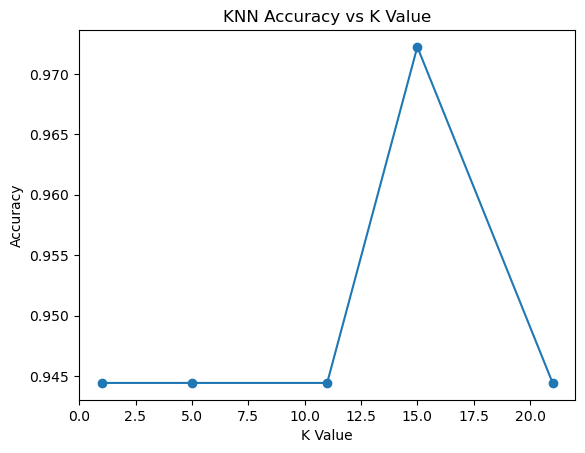

In [9]:
plt.plot(k_values, knn_accuracies, marker='o')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [10]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

In [11]:
for r in radius_values:
    model = RadiusNeighborsClassifier(radius=r)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    rnn_accuracies.append(acc)
    
    print(f"radius={r}, Accuracy={acc}")

radius=350, Accuracy=0.3888888888888889
radius=400, Accuracy=0.3888888888888889
radius=450, Accuracy=0.3888888888888889
radius=500, Accuracy=0.3888888888888889
radius=550, Accuracy=0.3888888888888889
radius=600, Accuracy=0.3888888888888889


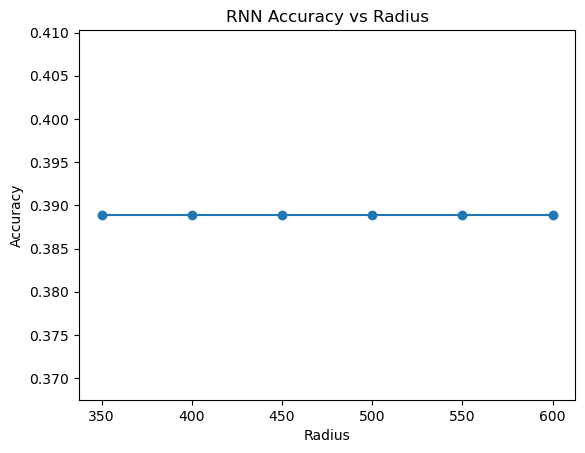

In [12]:
plt.plot(radius_values, rnn_accuracies, marker='o')
plt.title("RNN Accuracy vs Radius")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.show()

In [13]:
print("Best KNN Accuracy:", max(knn_accuracies))
print("Best RNN Accuracy:", max(rnn_accuracies))

Best KNN Accuracy: 0.9722222222222222
Best RNN Accuracy: 0.3888888888888889
